# Cycling Infrastructure Eindhoven — DS1 & DS3 Cleaning and EDA
**Group 15 — 2AMD20 Knowledge Engineering**

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

---
## 1. DS1 — Fietsenstallingen (Bike Parking Facilities)

### 1.1 Load and inspect

In [2]:
# DS1 uses semicolon separator; has a BOM character at start
ds1_raw = pd.read_csv('../data/raw/fietsenstallingen.csv', encoding='utf-8-sig', sep=';')

print(f'Shape: {ds1_raw.shape}')
print(f'Columns: {ds1_raw.columns.tolist()}')
ds1_raw.head()

Shape: (7, 17)
Columns: ['OBJECTID', 'NAAM_FIETSENSTALLING', 'ADRES_OMSCHRIJVING', 'TYPE_STALLING', 'OPENINGSTIJDEN_MAANDAG', 'OPENINGSTIJDEN_DINSDAG', 'OPENINGSTIJDEN_WOENSDAG', 'OPENINGSTIJDS_DONDERDAG', 'OPENINGSTIJDEN_VRIJDAG', 'OPENINGSTIJDEN_ZATERDAG', 'OPENINGSTIJDEN_ZONDAG', 'MEER_INFORMATIE', 'LONGITUDE', 'LATITUDE', 'geo_shape', 'geo_point_2d', 'geopoint']


,OBJECTID,NAAM_FIETSENSTALLING,ADRES_OMSCHRIJVING,TYPE_STALLING,OPENINGSTIJDEN_MAANDAG,OPENINGSTIJDEN_DINSDAG,OPENINGSTIJDEN_WOENSDAG,OPENINGSTIJDS_DONDERDAG,OPENINGSTIJDEN_VRIJDAG,OPENINGSTIJDEN_ZATERDAG,OPENINGSTIJDEN_ZONDAG,MEER_INFORMATIE,LONGITUDE,LATITUDE,geo_shape,geo_point_2d,geopoint
0,2,Fietsenstalling Winkelcentrum WoensXL,"Winkelcentrum Woensel 500-510, 5625 AA Eindhoven",Gratis fietsenstalling met toezicht,08:00-19:00uur,08:00-19:00uur,08:00-19:00uur,08:00-19:00uur,08:00-21:30uur,08:00-18:00uur,"alleen op koopzondagen toezicht, 11:00-18:00uur",https://www.eindhoven.nl/stad-en-wonen/verkeer...,5.473288,51.469785,"{""coordinates"": [5.4732884460401, 51.469785333...","51.46978533335247, 5.4732884460401","51.46978532, 5.47328846"
1,7,"Pop-up fietsenstalling Mercado, tijdelijke sta...","Smalle Haven 109, 5611 EH Eindhoven",Gratis fietsenstalling met toezicht,niet beschikbaar,niet beschikbaar,niet beschikbaar,niet beschikbaar,17:00-05:00 uur,17:00-05:00 uur,niet beschikbaar,https://www.eindhoven.nl/nieuws/proef-met-pop-...,5.481647,51.436996,"{""coordinates"": [5.481646994194696, 51.4369960...","51.43699601116056, 5.481646994194696","51.436996, 5.481647"
2,5,Fietsenstalling NS-station noordzijde,"Neckerspoel, 5611 AD Eindhoven",Bewaakte NS stalling (tegen betaling),06:30-20:00uur,06:30-20:00uur,06:30-20:00uur,06:30-20:00uur,06:30-20:00uur,gesloten,gesloten,https://www.ns.nl/fietsenstallingen/info/eindh...,5.478307,51.443333,"{""coordinates"": [5.478306836629171, 51.4433330...","51.44333306558167, 5.478306836629171","51.44333305, 5.47830684"
3,1,Fietsenstalling Heuvel,"Ten Hagestraat 14, 5611 EJ Eindhoven",Gratis fietsenstalling met toezicht,08:00-22:30uur,08:00-22:30uur,08:00-22:30uur,08:00-22:30uur,08:00-4:30uur,08:00-4:30uur,08:00-22:30uur,https://www.eindhoven.nl/stad-en-wonen/verkeer...,5.480458,51.437850,"{""coordinates"": [5.480458223533857, 51.4378504...","51.437850419905324, 5.480458223533857","51.43785041, 5.48045823"
4,3,Fietsenstalling 18 Septemberplein,"18 Septemberplein, 5611 AK, Eindhoven",Gratis fietsenstalling met toezicht,07:00-01:00uur,07:00-01:00uur,07:00-01:00uur,07:00-01:00uur,07:00-01:00uur,07:00-01:00uur,11:00-01:00uur,https://www.eindhoven.nl/stad-en-wonen/verkeer...,5.477071,51.441229,"{""coordinates"": [5.477070707060177, 51.4412288...","51.44122887025675, 5.477070707060177","51.44122886, 5.47707071"


In [3]:
capacity_map = {
    "Fietsenstalling 18 Septemberplein": 1400,
    "Fietsenstalling Heuvel": 900,
    "Fietsenstalling NS-station noordzijde": 200,
    "Fietsenstalling NS-station zuidzijde": 5000,
    "Fietsenstalling Winkelcentrum WoensXL": 200,
    "Pop-up fietsenstalling Kerkstraat, tijdelijke stalling zonder toezicht | 14 juni t/m 13 juli 2024": None,
    "Pop-up fietsenstalling Mercado, tijdelijke stalling zonder toezicht | 14 juni t/m 13 juli 2024": None
}

ds1_raw["CAPACITEIT"] = ds1_raw["NAAM_FIETSENSTALLING"].map(capacity_map)

In [4]:
# Data types and null counts
print('=== DTYPES & NULL COUNTS ===')
summary = pd.DataFrame({
    'dtype':    ds1_raw.dtypes,
    'nulls':    ds1_raw.isnull().sum(),
    'pct_null': (ds1_raw.isnull().mean() * 100).round(1),
    'unique':   ds1_raw.nunique()
})
print(summary.to_string())

=== DTYPES & NULL COUNTS ===
                           dtype  nulls  pct_null  unique
OBJECTID                   int64      0       0.0       7
NAAM_FIETSENSTALLING         str      0       0.0       7
ADRES_OMSCHRIJVING           str      0       0.0       7
TYPE_STALLING                str      0       0.0       2
OPENINGSTIJDEN_MAANDAG       str      0       0.0       6
OPENINGSTIJDEN_DINSDAG       str      0       0.0       6
OPENINGSTIJDEN_WOENSDAG      str      0       0.0       6
OPENINGSTIJDS_DONDERDAG      str      0       0.0       6
OPENINGSTIJDEN_VRIJDAG       str      0       0.0       6
OPENINGSTIJDEN_ZATERDAG      str      0       0.0       6
OPENINGSTIJDEN_ZONDAG        str      0       0.0       6
MEER_INFORMATIE              str      0       0.0       4
LONGITUDE                float64      0       0.0       7
LATITUDE                 float64      0       0.0       7
geo_shape                    str      0       0.0       7
geo_point_2d                 str      0    

### 1.2 Cleaning

In [5]:
ds1 = ds1_raw.copy()

# ── 1. Rename columns to English snake_case for KG consistency ─────────────
rename_map = {
    'OBJECTID':             'facility_id',
    'NAAM_FIETSENSTALLING': 'name',
    'ADRES_OMSCHRIJVING':   'address',
    'TYPE_STALLING':        'type',
    'LONGITUDE':            'lon',
    'LATITUDE':             'lat',
    'geo_point_2d':         'geo_point',
    'geo_shape':            'geo_shape',
}
# Only rename columns that exist
rename_actual = {k: v for k, v in rename_map.items() if k in ds1.columns}
ds1.rename(columns=rename_actual, inplace=True)

# Also handle capacity if present
if 'CAPACITEIT' in ds1.columns:
    ds1.rename(columns={'CAPACITEIT': 'capacity'}, inplace=True)
if 'BEWAAKT' in ds1.columns:
    ds1.rename(columns={'BEWAAKT': 'supervised_raw'}, inplace=True)

print('Renamed columns:', list(rename_actual.values()))
ds1.head(3)

Renamed columns: ['facility_id', 'name', 'address', 'type', 'lon', 'lat', 'geo_point', 'geo_shape']


,facility_id,name,address,type,OPENINGSTIJDEN_MAANDAG,OPENINGSTIJDEN_DINSDAG,OPENINGSTIJDEN_WOENSDAG,OPENINGSTIJDS_DONDERDAG,OPENINGSTIJDEN_VRIJDAG,OPENINGSTIJDEN_ZATERDAG,OPENINGSTIJDEN_ZONDAG,MEER_INFORMATIE,lon,lat,geo_shape,geo_point,geopoint,capacity
0,2,Fietsenstalling Winkelcentrum WoensXL,"Winkelcentrum Woensel 500-510, 5625 AA Eindhoven",Gratis fietsenstalling met toezicht,08:00-19:00uur,08:00-19:00uur,08:00-19:00uur,08:00-19:00uur,08:00-21:30uur,08:00-18:00uur,"alleen op koopzondagen toezicht, 11:00-18:00uur",https://www.eindhoven.nl/stad-en-wonen/verkeer...,5.473288,51.469785,"{""coordinates"": [5.4732884460401, 51.469785333...","51.46978533335247, 5.4732884460401","51.46978532, 5.47328846",200.0
1,7,"Pop-up fietsenstalling Mercado, tijdelijke sta...","Smalle Haven 109, 5611 EH Eindhoven",Gratis fietsenstalling met toezicht,niet beschikbaar,niet beschikbaar,niet beschikbaar,niet beschikbaar,17:00-05:00 uur,17:00-05:00 uur,niet beschikbaar,https://www.eindhoven.nl/nieuws/proef-met-pop-...,5.481647,51.436996,"{""coordinates"": [5.481646994194696, 51.4369960...","51.43699601116056, 5.481646994194696","51.436996, 5.481647",NaN
2,5,Fietsenstalling NS-station noordzijde,"Neckerspoel, 5611 AD Eindhoven",Bewaakte NS stalling (tegen betaling),06:30-20:00uur,06:30-20:00uur,06:30-20:00uur,06:30-20:00uur,06:30-20:00uur,gesloten,gesloten,https://www.ns.nl/fietsenstallingen/info/eindh...,5.478307,51.443333,"{""coordinates"": [5.478306836629171, 51.4433330...","51.44333306558167, 5.478306836629171","51.44333305, 5.47830684",200.0


In [6]:
# ── 2. Parse lat/lon from geo_point if dedicated columns are missing ────────
if 'lat' not in ds1.columns and 'geo_point' in ds1.columns:
    # format: '51.4435, 5.4796'
    coords = ds1['geo_point'].str.split(',', expand=True)
    ds1['lat'] = pd.to_numeric(coords[0].str.strip(), errors='coerce')
    ds1['lon'] = pd.to_numeric(coords[1].str.strip(), errors='coerce')
    print('Parsed lat/lon from geo_point column')
elif 'lat' in ds1.columns:
    ds1['lat'] = pd.to_numeric(ds1['lat'], errors='coerce')
    ds1['lon'] = pd.to_numeric(ds1['lon'], errors='coerce')

# ── 3. Map supervised: Ja → True, Nee → False ──────────────────────────────
if 'supervised_raw' in ds1.columns:
    ds1['supervised'] = ds1['supervised_raw'].str.lower().map({'ja': True, 'nee': False})
    ds1.drop(columns=['supervised_raw'], inplace=True)
    print('Mapped supervised: Ja→True, Nee→False')

# ── 4. Capacity: convert to int if present ─────────────────────────────────
if 'capacity' in ds1.columns:
    ds1['capacity'] = pd.to_numeric(ds1['capacity'], errors='coerce')
    print(f'Capacity range: {ds1.capacity.min()} – {ds1.capacity.max()}')

# ── 5. Drop redundant geometry/opening-hours columns for KG CSV ────────────
OPENING_COLS = [c for c in ds1.columns if 'OPENINGSTIJD' in c.upper()]
EXTRA_COLS   = ['geopoint', 'MEER_INFORMATIE', 'geo_shape']
DROP_COLS    = [c for c in OPENING_COLS + EXTRA_COLS if c in ds1.columns]
ds1.drop(columns=DROP_COLS, inplace=True)
print(f'Dropped {len(DROP_COLS)} auxiliary columns: {DROP_COLS}')

# ── 6. Drop rows with missing coordinates ──────────────────────────────────
before = len(ds1)
ds1.dropna(subset=['lat', 'lon'], inplace=True)
print(f'Dropped {before - len(ds1)} rows missing coordinates')

print(f'\nClean DS1 shape: {ds1.shape}')
ds1.head()

Capacity range: 200.0 – 5000.0
Dropped 10 auxiliary columns: ['OPENINGSTIJDEN_MAANDAG', 'OPENINGSTIJDEN_DINSDAG', 'OPENINGSTIJDEN_WOENSDAG', 'OPENINGSTIJDS_DONDERDAG', 'OPENINGSTIJDEN_VRIJDAG', 'OPENINGSTIJDEN_ZATERDAG', 'OPENINGSTIJDEN_ZONDAG', 'geopoint', 'MEER_INFORMATIE', 'geo_shape']
Dropped 0 rows missing coordinates

Clean DS1 shape: (7, 8)


,facility_id,name,address,type,lon,lat,geo_point,capacity
0,2,Fietsenstalling Winkelcentrum WoensXL,"Winkelcentrum Woensel 500-510, 5625 AA Eindhoven",Gratis fietsenstalling met toezicht,5.473288,51.469785,"51.46978533335247, 5.4732884460401",200.0
1,7,"Pop-up fietsenstalling Mercado, tijdelijke sta...","Smalle Haven 109, 5611 EH Eindhoven",Gratis fietsenstalling met toezicht,5.481647,51.436996,"51.43699601116056, 5.481646994194696",NaN
2,5,Fietsenstalling NS-station noordzijde,"Neckerspoel, 5611 AD Eindhoven",Bewaakte NS stalling (tegen betaling),5.478307,51.443333,"51.44333306558167, 5.478306836629171",200.0
3,1,Fietsenstalling Heuvel,"Ten Hagestraat 14, 5611 EJ Eindhoven",Gratis fietsenstalling met toezicht,5.480458,51.437850,"51.437850419905324, 5.480458223533857",900.0
4,3,Fietsenstalling 18 Septemberplein,"18 Septemberplein, 5611 AK, Eindhoven",Gratis fietsenstalling met toezicht,5.477071,51.441229,"51.44122887025675, 5.477070707060177",1400.0


In [7]:
# ── 7. Validate coordinate bounding box for Eindhoven ──────────────────────
# Eindhoven approx bbox: lat 51.38–51.50, lon 5.38–5.56
LAT_MIN, LAT_MAX = 51.38, 51.50
LON_MIN, LON_MAX = 5.38, 5.56

out_of_bbox = ds1[
    (ds1['lat'] < LAT_MIN) | (ds1['lat'] > LAT_MAX) |
    (ds1['lon'] < LON_MIN) | (ds1['lon'] > LON_MAX)
]

if len(out_of_bbox) > 0:
    print(f'⚠️  {len(out_of_bbox)} facilities outside Eindhoven bounding box:')
    print(out_of_bbox[['facility_id', 'name', 'lat', 'lon']].to_string())
else:
    print(f'✅ All {len(ds1)} facilities within Eindhoven bounding box')
    print(f'   Lat range: {ds1.lat.min():.4f} – {ds1.lat.max():.4f}')
    print(f'   Lon range: {ds1.lon.min():.4f} – {ds1.lon.max():.4f}')

✅ All 7 facilities within Eindhoven bounding box
   Lat range: 51.4370 – 51.4698
   Lon range: 5.4733 – 5.4816


In [8]:
# ── 8. Final null check ────────────────────────────────────────────────────
print('Null counts in clean DS1:')
print(ds1.isnull().sum()[ds1.isnull().sum() > 0])
if ds1.isnull().sum().sum() == 0:
    print('No nulls remaining.')

Null counts in clean DS1:
capacity    2
dtype: int64


### 1.3 EDA — Fietsenstallingen

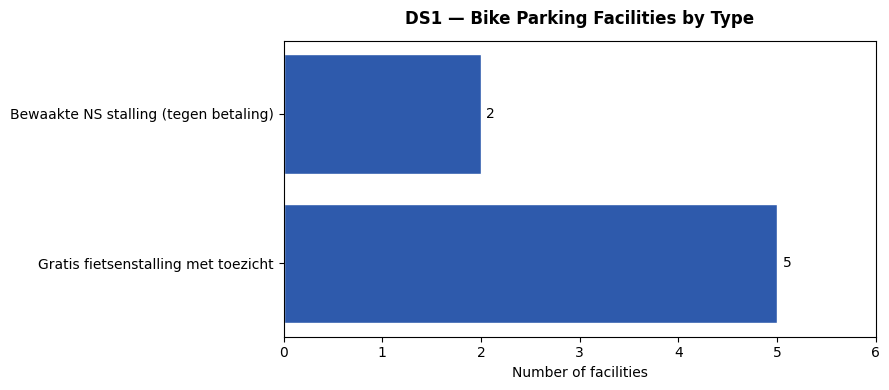

type
Gratis fietsenstalling met toezicht      5
Bewaakte NS stalling (tegen betaling)    2


In [9]:
# ── EDA 1: Type distribution ───────────────────────────────────────────────
if 'type' in ds1.columns:
    type_counts = ds1['type'].value_counts()
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(type_counts.index, type_counts.values, color="#2E5AAC", edgecolor='white')
    ax.bar_label(bars, padding=4, fontsize=10)
    ax.set_xlabel('Number of facilities')
    ax.set_title('DS1 — Bike Parking Facilities by Type', fontweight='bold', pad=12)
    ax.set_xlim(0, type_counts.max() * 1.2)
    plt.tight_layout()
    plt.savefig('../figures/ds1_type_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(type_counts.to_string())

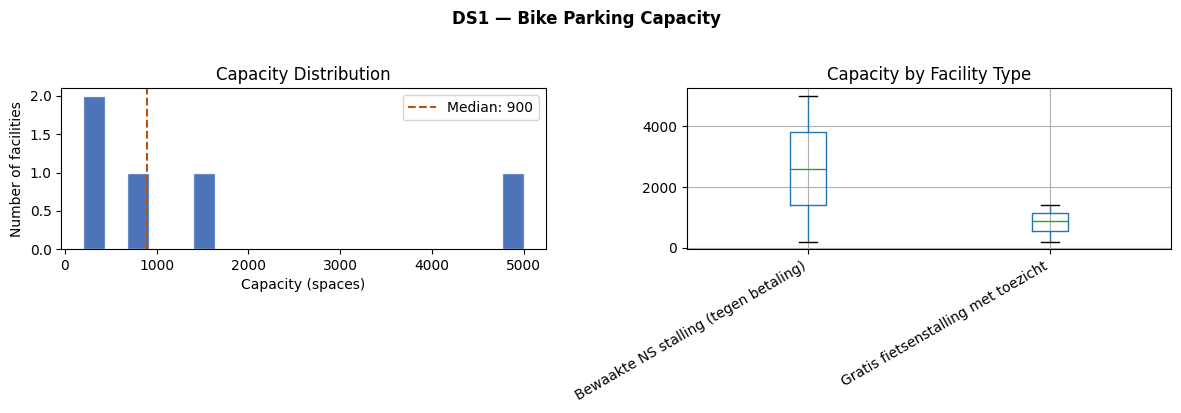

Capacity statistics:
count       5.0
mean     1540.0
std      1999.5
min       200.0
25%       200.0
50%       900.0
75%      1400.0
max      5000.0
Name: capacity, dtype: float64

Total capacity across all facilities: 7700 spaces


In [10]:
# ── EDA 2: Capacity distribution (if column present) ──────────────────────
if 'capacity' in ds1.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axes[0].hist(ds1['capacity'].dropna(), bins=20, color="#2E5AAC", edgecolor='white', alpha=0.85)
    axes[0].set_xlabel('Capacity (spaces)')
    axes[0].set_ylabel('Number of facilities')
    axes[0].set_title('Capacity Distribution')
    axes[0].axvline(ds1['capacity'].median(), color="#B45309", linestyle='--', label=f"Median: {ds1['capacity'].median():.0f}")
    axes[0].legend()

    # Box plot by type
    if 'type' in ds1.columns:
        types = ds1.dropna(subset=['capacity', 'type'])
        types.boxplot(column='capacity', by='type', ax=axes[1], grid=True)
        axes[1].set_title('Capacity by Facility Type')
        axes[1].set_xlabel('')
        plt.sca(axes[1])
        plt.xticks(rotation=30, ha='right')
        plt.suptitle('')

    plt.suptitle('DS1 — Bike Parking Capacity', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../figures/ds1_capacity.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Capacity statistics:')
    print(ds1['capacity'].describe().round(1))
    print(f'\nTotal capacity across all facilities: {ds1["capacity"].sum():.0f} spaces')

In [11]:
# ── EDA 3: Supervised vs unsupervised breakdown ────────────────────────────
if 'supervised' in ds1.columns:
    sup_counts = ds1['supervised'].value_counts()
    fig, ax = plt.subplots(figsize=(5, 4))
    wedges, texts, autotexts = ax.pie(
        sup_counts.values,
        labels=['Supervised' if k else 'Unsupervised' for k in sup_counts.index],
        autopct='%1.1f%%',
        colors=["#1B5E35", "#B45309"],
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    ax.set_title('DS1 — Supervised vs Unsupervised Parking', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figures/ds1_supervised.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(sup_counts.rename({True: 'Supervised', False: 'Unsupervised'}).to_string())

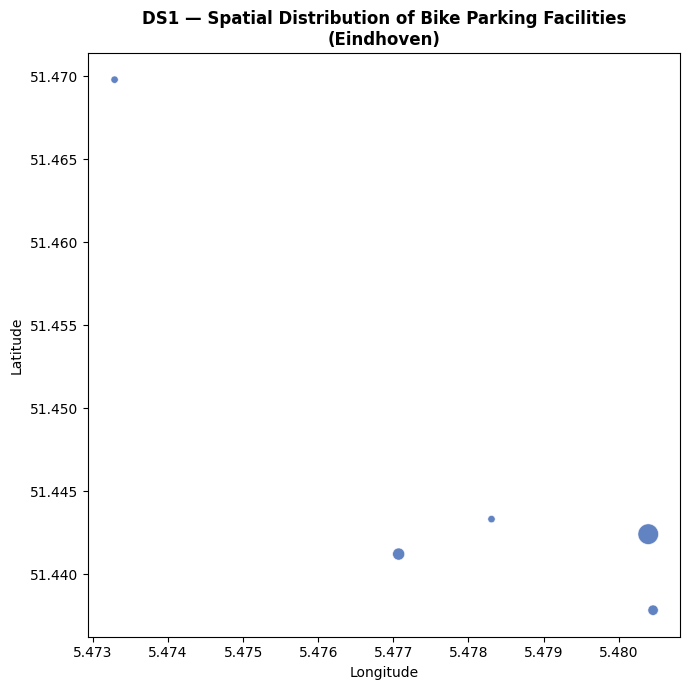

Plotted 7 facilities


In [12]:
# ── EDA 4: Spatial scatter of facilities ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

color_col = 'supervised' if 'supervised' in ds1.columns else None
size_col  = 'capacity'   if 'capacity'   in ds1.columns else None

if color_col:
    colors = ds1[color_col].map({True: "#1B5E35", False: "#B45309", None: "#2E5AAC"})
else:
    colors = "#2E5AAC"

sizes = (ds1[size_col] / ds1[size_col].max() * 200 + 20) if size_col else 40

ax.scatter(ds1['lon'], ds1['lat'], c=colors, s=sizes, alpha=0.75, edgecolors='white', linewidths=0.5)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('DS1 — Spatial Distribution of Bike Parking Facilities\n(Eindhoven)', fontweight='bold')

if color_col:
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor="#1B5E35", label='Supervised'),
                       Patch(facecolor="#B45309", label='Unsupervised')]
    ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../figures/ds1_spatial.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plotted {len(ds1)} facilities')

In [13]:
# ── Save clean DS1 ─────────────────────────────────────────────────────────
ds1.to_csv('../data/clean/ds1.csv', index=False)
print(f'Saved: ds1.csv ({len(ds1)} rows, {len(ds1.columns)} columns)')
print('Columns:', ds1.columns.tolist())

Saved: ds1.csv (7 rows, 8 columns)
Columns: ['facility_id', 'name', 'address', 'type', 'lon', 'lat', 'geo_point', 'capacity']


In [14]:
import folium
from folium import plugins
from IPython.display import display

# ── Create base map centered on Eindhoven ──────────────────────────────────
center_lat = ds1['lat'].mean()
center_lon = ds1['lon'].mean()

map_eindhoven = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=13,
    tiles='CartoDB positron'
)

# ── Add markers for each bike parking facility ──────────────────────────────
for idx, row in ds1.iterrows():
    # Create popup with facility information
    popup_text = f"""
    <b>{row['name']}</b><br>
    Type: {row['type']}<br>
    Address: {row['address']}<br>
    Coordinates: ({row['lat']:.4f}, {row['lon']:.4f})
    """
    
    # Color code by type (if supervised)
    if 'supervised' in row and row['supervised']:
        color = 'green'
        icon_char = '✓'
    else:
        color = 'blue'
        icon_char = '🚴'
    
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=row['name'],
        icon=folium.Icon(color=color, icon='info-sign', prefix='glyphicon')
    ).add_to(map_eindhoven)

# ── Add layer control and save ─────────────────────────────────────────────
map_eindhoven.save('../figures/bike_parking_map.html')
print(f'✅ Map created and saved: bike_parking_map.html')
print(f'   Markers: {len(ds1)} bike parking facilities')
print(f'   Center: ({center_lat:.4f}, {center_lon:.4f})')

# Display the map
map_eindhoven

✅ Map created and saved: bike_parking_map.html
   Markers: 7 bike parking facilities
   Center: (51.4441, 5.4786)


---
## 2. DS3 — CBS Kerncijfers Wijken en Buurten 2025

In [15]:
pop_df = pd.read_csv("../data/raw/Inwoners - Buurten [117].csv", sep=";")
pop_df.head()

,Niveau,Inwoners|1950,Inwoners|1951,Inwoners|1952,Inwoners|1953,Inwoners|1954,Inwoners|1955,Inwoners|1956,Inwoners|1957,Inwoners|1958,...,Inwoners|2017,Inwoners|2018,Inwoners|2019,Inwoners|2020,Inwoners|2021,Inwoners|2022,Inwoners|2023,Inwoners|2024,Inwoners|2025,Inwoners|2026
0,Buurt Achtse Barrier-Gunterslaer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3754,3728,3737,3721,3711,3695,3717,3742,3773,NaN
1,Buurt Achtse Barrier-Hoeven,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4048,4013,4005,3989,3936,3883,3907,3885,3886,NaN
2,Buurt Achtse Barrier-Spaaihoef,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4549,4554,4517,4505,4474,4470,4471,4521,4524,NaN
3,Buurt Barrier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2195,2168,2143,2130,2077,2045,2040,2047,2040,NaN
4,Buurt BeA2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,31,27,30,25,26,32,31,28,23,NaN


In [16]:
pop_df["BUURTNAAM"] = pop_df["Niveau"].str.replace("^Buurt ", "", regex=True)

In [17]:
buurten_df = pd.read_csv("../data/raw/buurten.csv", sep=";")
buurten_df.head()

,BUURTCODE,BUURTNAAM,WIJKCODE,WIJKNAAM,STADSDEELCODE,STADSDEELNAAM,OBJECTID,OPPERVLAKTE,SHAPE.LEN,geo_shape,geo_point_2d
0,543,Vaartbroek,54,Wijk Dommelbeemd,5,Stadsdeel Woensel-Noord,25,1011875,4300.438299,"{""coordinates"": [[[5.492520090952543, 51.48227...","51.478597626687694, 5.4986383772478105"
1,231,Poeijers,23,Wijk Putten,2,Stadsdeel Stratum,28,964893,5033.796762,"{""coordinates"": [[[5.518752117996803, 51.43341...","51.43123371620276, 5.518225262058485"
2,336,Karpen,33,Wijk Oud-Tongelre,3,Stadsdeel Tongelre,31,928066,3794.553430,"{""coordinates"": [[[5.49829999177369, 51.457664...","51.45300224128063, 5.503009777600558"
3,638,Eindhoven Airport,63,Wijk Meerhoven,6,Stadsdeel Strijp,1,6386346,13423.941335,"{""coordinates"": [[[5.395278924462285, 51.44678...","51.452421397452056, 5.3766454520629265"
4,628,Mispelhoef,62,Wijk Halve Maan,6,Stadsdeel Strijp,2,2961942,7168.139846,"{""coordinates"": [[[5.42059106945369, 51.477716...","51.472090866116886, 5.414670017612557"


In [18]:
merged = pop_df.merge(
    buurten_df,
    on="BUURTNAAM",
    how="left"
)

In [19]:
missing = merged[merged["geo_shape"].isna()]

print(missing["BUURTNAAM"].unique())

<StringArray>
['Onbekend', 'Eindhoven']
Length: 2, dtype: str


"Onbekend" = unknown location, not an actual neighborhood
"Eindhoven" = city-level total, not a buurt polygon

So  merge worked correctly for the actual neighborhoods.

In [20]:
merged = merged[
    ~merged["BUURTNAAM"].isin(["Onbekend", "Eindhoven"])
]

In [21]:
merged.head()

,Niveau,Inwoners|1950,Inwoners|1951,Inwoners|1952,Inwoners|1953,Inwoners|1954,Inwoners|1955,Inwoners|1956,Inwoners|1957,Inwoners|1958,...,BUURTCODE,WIJKCODE,WIJKNAAM,STADSDEELCODE,STADSDEELNAAM,OBJECTID,OPPERVLAKTE,SHAPE.LEN,geo_shape,geo_point_2d
0,Buurt Achtse Barrier-Gunterslaer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,522.0,52.0,Wijk Achtse Molen,5.0,Stadsdeel Woensel-Noord,24.0,1015385.0,4710.687538,"{""coordinates"": [[[5.45625536423871, 51.479033...","51.48035368406392, 5.447327775016037"
1,Buurt Achtse Barrier-Hoeven,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,524.0,52.0,Wijk Achtse Molen,5.0,Stadsdeel Woensel-Noord,43.0,744208.0,3647.832287,"{""coordinates"": [[[5.444884639883207, 51.48575...","51.49045018427772, 5.445992380298528"
2,Buurt Achtse Barrier-Spaaihoef,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,523.0,52.0,Wijk Achtse Molen,5.0,Stadsdeel Woensel-Noord,23.0,1015941.0,5252.710205,"{""coordinates"": [[[5.439586926395638, 51.48854...","51.48633901671497, 5.437133411484463"
3,Buurt Barrier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,423.0,42.0,Wijk Erp,4.0,Stadsdeel Woensel-Zuid,99.0,257473.0,2110.141942,"{""coordinates"": [[[5.454851547237404, 51.46224...","51.46077134206934, 5.459137196418091"
4,Buurt BeA2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,631.0,63.0,Wijk Meerhoven,6.0,Stadsdeel Strijp,3.0,2620191.0,8769.133586,"{""coordinates"": [[[5.393934485995225, 51.46433...","51.47225767052634, 5.398982737468006"


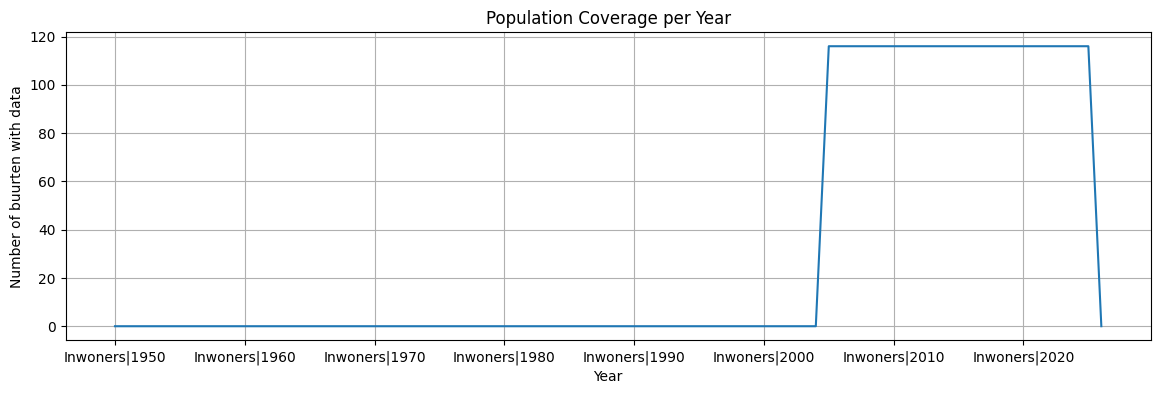

In [22]:
year_cols = [c for c in merged.columns if c.startswith("Inwoners|")]

coverage = (
    merged[year_cols]
    .notna()
    .sum()
)

# # Show top years with best coverage
# print("\nBest coverage years:")
# print(coverage.sort_values(ascending=False).head(15))

# Plot coverage
plt.figure(figsize=(14,4))
coverage.plot()
plt.title("Population Coverage per Year")
plt.ylabel("Number of buurten with data")
plt.xlabel("Year")
plt.grid(True)
plt.show()

# --------------------------------------------------
# 6. KEEP ONLY 2005–2025
# --------------------------------------------------

selected_years = [
    c for c in year_cols
    if 2005 <= int(c.split("|")[1]) <= 2025
]

keep_cols = [
    "BUURTNAAM",
    "BUURTCODE",
    "WIJKNAAM",
    "STADSDEELNAAM",
    "geo_shape"
] + selected_years

ds3 = merged[keep_cols].copy()

In [23]:
ds3

,BUURTNAAM,BUURTCODE,WIJKNAAM,STADSDEELNAAM,geo_shape,Inwoners|2005,Inwoners|2006,Inwoners|2007,Inwoners|2008,Inwoners|2009,...,Inwoners|2016,Inwoners|2017,Inwoners|2018,Inwoners|2019,Inwoners|2020,Inwoners|2021,Inwoners|2022,Inwoners|2023,Inwoners|2024,Inwoners|2025
0,Achtse Barrier-Gunterslaer,522.0,Wijk Achtse Molen,Stadsdeel Woensel-Noord,"{""coordinates"": [[[5.45625536423871, 51.479033...",4092,4029,3954,3932,3901,...,3737,3754,3728,3737,3721,3711,3695,3717,3742,3773
1,Achtse Barrier-Hoeven,524.0,Wijk Achtse Molen,Stadsdeel Woensel-Noord,"{""coordinates"": [[[5.444884639883207, 51.48575...",4467,4425,4316,4341,4304,...,4087,4048,4013,4005,3989,3936,3883,3907,3885,3886
2,Achtse Barrier-Spaaihoef,523.0,Wijk Achtse Molen,Stadsdeel Woensel-Noord,"{""coordinates"": [[[5.439586926395638, 51.48854...",4876,4900,4855,4874,4818,...,4603,4549,4554,4517,4505,4474,4470,4471,4521,4524
3,Barrier,423.0,Wijk Erp,Stadsdeel Woensel-Zuid,"{""coordinates"": [[[5.454851547237404, 51.46224...",1601,1639,1738,1948,2154,...,2252,2195,2168,2143,2130,2077,2045,2040,2047,2040
4,BeA2,631.0,Wijk Meerhoven,Stadsdeel Strijp,"{""coordinates"": [[[5.393934485995225, 51.46433...",144,61,94,52,40,...,29,31,27,30,25,26,32,31,28,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,Woenselse Heide,531.0,Wijk Aanschot,Stadsdeel Woensel-Noord,"{""coordinates"": [[[5.459703993418563, 51.48346...",5110,5122,5118,5062,5056,...,5207,5145,5139,5170,5252,5229,5268,5264,5287,5255
112,Woenselse Watermolen,414.0,Wijk Oud-Woensel,Stadsdeel Woensel-Zuid,"{""coordinates"": [[[5.480378012450603, 51.44638...",1049,1076,1104,1086,1087,...,1223,1285,1312,1349,1362,1363,1395,1611,1646,1653
113,Woensel-West,421.0,Wijk Erp,Stadsdeel Woensel-Zuid,"{""coordinates"": [[[5.464184318759506, 51.45172...",4126,4214,4204,4108,4096,...,4126,3976,3799,3782,3878,4375,4518,5167,5850,5895
114,Zandrijk,634.0,Wijk Meerhoven,Stadsdeel Strijp,"{""coordinates"": [[[5.410135597000532, 51.45076...",2603,2681,2701,2882,2904,...,2996,3009,2959,2972,2940,2917,2883,2911,2864,2808


In [24]:
import geopandas as gpd
from shapely.geometry import shape
import json

ds3["geometry"] = ds3["geo_shape"].apply(
    lambda x: shape(json.loads(x))
)

ds3 = gpd.GeoDataFrame(
    ds3,
    geometry="geometry",
    crs="EPSG:4326"
)

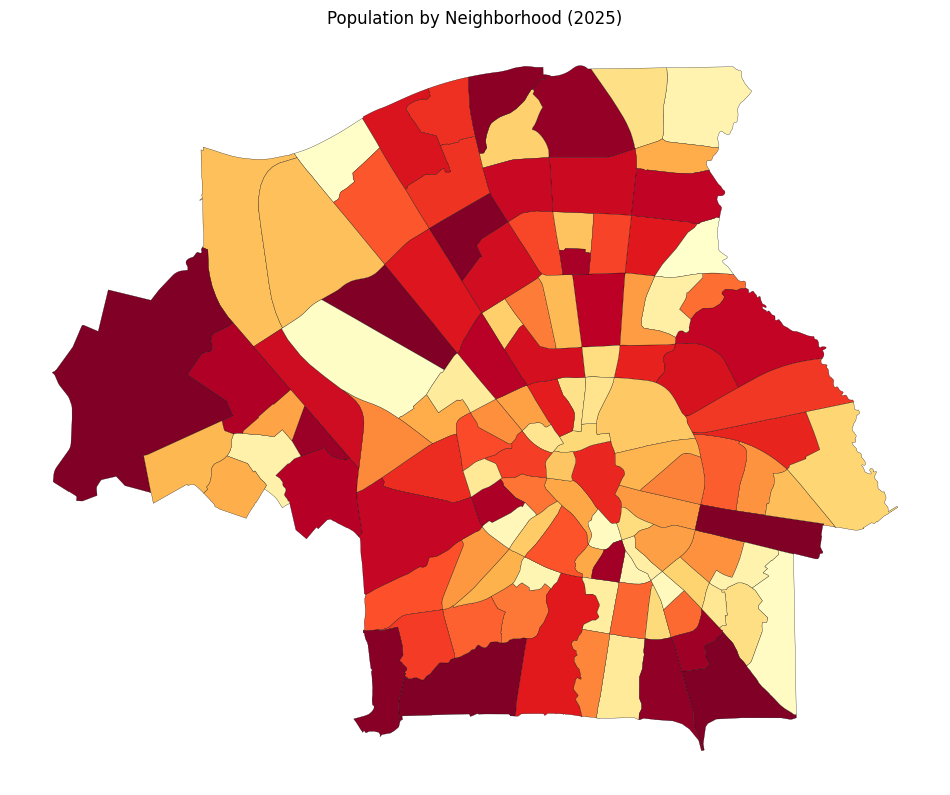

In [25]:
fig, ax = plt.subplots(figsize=(12,12))

ds3.plot(
    column="Inwoners|2025",
    cmap="YlOrRd",      # gradient color palette
    scheme=None,        # continuous scale
    # legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

ax.set_title("Population by Neighborhood (2025)")
ax.axis("off")

plt.savefig('../figures/ds3_pop_by_neighborhood.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Engineering

In [26]:
ds3["pop_2025"] = ds3["Inwoners|2025"]
ds3["pop_2020"] = ds3["Inwoners|2020"]
ds3["pop_2010"] = ds3["Inwoners|2010"]

In [27]:
pop_cols = [c for c in ds3.columns if "Inwoners|" in c]

ds3[pop_cols] = ds3[pop_cols].apply(pd.to_numeric, errors="coerce")

In [28]:
ds3["pop_growth_rate"] = (
    (ds3["Inwoners|2025"] - ds3["Inwoners|2005"])
    / ds3["Inwoners|2005"]
)

ds3["pop_growth_2005_2025"] = (
    ds3["Inwoners|2025"] - ds3["Inwoners|2005"]
)

In [29]:
import geopandas as gpd
import json
from shapely.geometry import shape

ds3["geometry"] = ds3["geo_shape"].apply(
    lambda x: shape(json.loads(x)) if isinstance(x, str) else None
)

ds3 = gpd.GeoDataFrame(ds3, geometry="geometry", crs="EPSG:4326")
ds3 = ds3.to_crs(epsg=28992)

ds3["area_km2"] = ds3["geometry"].area / 1e6

In [30]:
ds3.columns.tolist()

['BUURTNAAM',
 'BUURTCODE',
 'WIJKNAAM',
 'STADSDEELNAAM',
 'geo_shape',
 'Inwoners|2005',
 'Inwoners|2006',
 'Inwoners|2007',
 'Inwoners|2008',
 'Inwoners|2009',
 'Inwoners|2010',
 'Inwoners|2011',
 'Inwoners|2012',
 'Inwoners|2013',
 'Inwoners|2014',
 'Inwoners|2015',
 'Inwoners|2016',
 'Inwoners|2017',
 'Inwoners|2018',
 'Inwoners|2019',
 'Inwoners|2020',
 'Inwoners|2021',
 'Inwoners|2022',
 'Inwoners|2023',
 'Inwoners|2024',
 'Inwoners|2025',
 'geometry',
 'pop_2025',
 'pop_2020',
 'pop_2010',
 'pop_growth_rate',
 'pop_growth_2005_2025',
 'area_km2']

- Spatial / administrative:
BUURTNAAM, BUURTCODE, WIJKNAAM, STADSDEELNAAM
geo_shape / geometry
- Population (time series):
Inwoners|2005 … Inwoners|2025
- Engineered features:
pop_2025, pop_2020, pop_2010
pop_growth_rate, pop_growth_2005_2025, area_km2

In [31]:
ds3["population"] = pd.to_numeric(ds3["pop_2025"], errors="coerce")
ds3["area_km2"] = pd.to_numeric(ds3["area_km2"], errors="coerce")

# --- drop invalid rows ---
ds3 = ds3.dropna(subset=["population", "area_km2"])

# --- core derived features ---
ds3["OAD"] = ds3["population"] / ds3["area_km2"]
ds3["pop_density"] = ds3["population"] / ds3["area_km2"]

ds3["pop_growth_rate"] = pd.to_numeric(ds3["pop_growth_rate"], errors="coerce")

ds3["urban_pressure"] = ds3["pop_density"] * np.log1p(ds3["population"])
ds3["growth_pressure"] = ds3["pop_growth_rate"] * ds3["pop_density"]

ds3.head()

,BUURTNAAM,BUURTCODE,WIJKNAAM,STADSDEELNAAM,geo_shape,Inwoners|2005,Inwoners|2006,Inwoners|2007,Inwoners|2008,Inwoners|2009,...,pop_2020,pop_2010,pop_growth_rate,pop_growth_2005_2025,area_km2,population,OAD,pop_density,urban_pressure,growth_pressure
0,Achtse Barrier-Gunterslaer,522.0,Wijk Achtse Molen,Stadsdeel Woensel-Noord,"{""coordinates"": [[[5.45625536423871, 51.479033...",4092.0,4029.0,3954.0,3932.0,3901.0,...,3721,3880,-0.077957,-319.0,1.015387,3773.0,3715.825734,3715.825734,30603.134701,-289.674587
1,Achtse Barrier-Hoeven,524.0,Wijk Achtse Molen,Stadsdeel Woensel-Noord,"{""coordinates"": [[[5.444884639883207, 51.48575...",4467.0,4425.0,4316.0,4341.0,4304.0,...,3989,4260,-0.130065,-581.0,0.744209,3886.0,5221.648554,5221.648554,43158.977043,-679.153304
2,Achtse Barrier-Spaaihoef,523.0,Wijk Achtse Molen,Stadsdeel Woensel-Noord,"{""coordinates"": [[[5.439586926395638, 51.48854...",4876.0,4900.0,4855.0,4874.0,4818.0,...,4505,4755,-0.072190,-352.0,1.015942,4524.0,4453.010370,4453.010370,37482.648615,-321.464243
3,Barrier,423.0,Wijk Erp,Stadsdeel Woensel-Zuid,"{""coordinates"": [[[5.454851547237404, 51.46224...",1601.0,1639.0,1738.0,1948.0,2154.0,...,2130,2129,0.274204,439.0,0.257474,2040.0,7923.122667,7923.122667,60383.664147,2172.548939
4,BeA2,631.0,Wijk Meerhoven,Stadsdeel Strijp,"{""coordinates"": [[[5.393934485995225, 51.46433...",144.0,61.0,94.0,52.0,40.0,...,25,50,-0.840278,-121.0,2.620186,23.0,8.778001,8.778001,27.896961,-7.375959


In [32]:
# --- Urban pressure score (combines density + size pressure) ---
ds3["urban_pressure"] = ds3["pop_density"] * np.log1p(ds3["population"])

# --- Growth vs density tension (useful for future demand) ---
ds3["growth_pressure"] = ds3["pop_growth_rate"] * ds3["pop_density"]

# --- Normalized scores (for ranking in Neo4j / analysis) ---
ds3["pop_density_z"] = (ds3["pop_density"] - ds3["pop_density"].mean()) / ds3["pop_density"].std()
ds3["OAD_z"] = (ds3["OAD"] - ds3["OAD"].mean()) / ds3["OAD"].std()

1. urban pressure: where many people live + space is tight. use to find high-demand cycling areas (infrastructure stress is naturally high) --> answers RQ5
2. growth pressure: where population is growing and already dense. use it to predict future cycling problems. 
3. pop_density_z and OAD_z: standardized scores; tells how extreme a neighborhood is compared to ehv average. use it to rank neighborhoods fairly. if:
    - (>2): extremely dense, 
    - (>1) above average,
    - 0: average
    - (<-1): below average. 


In [33]:
ds3.columns.tolist()

['BUURTNAAM',
 'BUURTCODE',
 'WIJKNAAM',
 'STADSDEELNAAM',
 'geo_shape',
 'Inwoners|2005',
 'Inwoners|2006',
 'Inwoners|2007',
 'Inwoners|2008',
 'Inwoners|2009',
 'Inwoners|2010',
 'Inwoners|2011',
 'Inwoners|2012',
 'Inwoners|2013',
 'Inwoners|2014',
 'Inwoners|2015',
 'Inwoners|2016',
 'Inwoners|2017',
 'Inwoners|2018',
 'Inwoners|2019',
 'Inwoners|2020',
 'Inwoners|2021',
 'Inwoners|2022',
 'Inwoners|2023',
 'Inwoners|2024',
 'Inwoners|2025',
 'geometry',
 'pop_2025',
 'pop_2020',
 'pop_2010',
 'pop_growth_rate',
 'pop_growth_2005_2025',
 'area_km2',
 'population',
 'OAD',
 'pop_density',
 'urban_pressure',
 'growth_pressure',
 'pop_density_z',
 'OAD_z']

### 2.3 EDA — CBS Kerncijfers

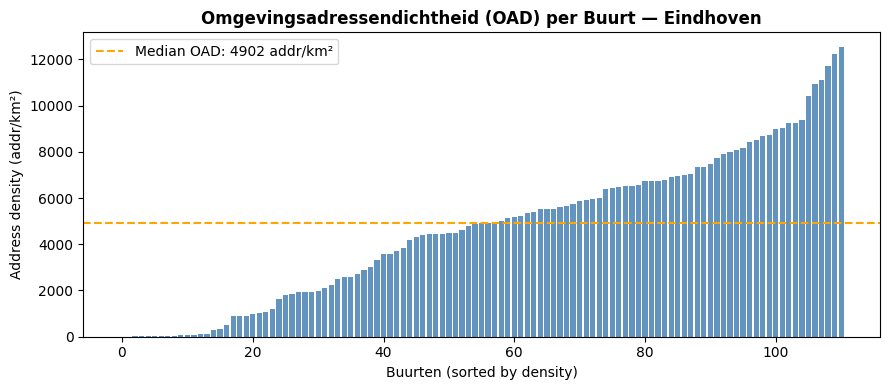

OAD stats:
 count      111.0
mean      4670.0
std       3221.0
min          8.0
25%       1921.0
50%       4902.0
75%       6755.0
max      12542.0
Name: OAD, dtype: float64

High-density buurten (OAD > median):
                   BUURTNAAM          OAD
                 Rochusbuurt 12542.138949
                  Witte Dame 12248.260545
                Kruidenbuurt 11704.793324
                 Hemelrijken 11118.718230
Eliasterrein, Vonderkwartier 10953.883036
                    Strijp S 10418.650053
               Limbeek-Noord  9361.845783
                      Schoot  9257.042045
                Bloemenplein  9248.541222
               Joriskwartier  9008.692609


<Figure size 640x480 with 0 Axes>

In [34]:
df_eda = ds3.copy()

# --- ensure numeric ---
df_eda["OAD"] = pd.to_numeric(df_eda["OAD"], errors="coerce")

# --- valid values ---
oad = df_eda["OAD"].dropna().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    range(len(oad)),
    oad.values,
    color="steelblue",
    edgecolor="none",
    alpha=0.85
)

ax.axhline(
    oad.median(),
    color="orange",
    linestyle="--",
    label=f"Median OAD: {oad.median():.0f} addr/km²"
)

ax.set_xlabel("Buurten (sorted by density)")
ax.set_ylabel("Address density (addr/km²)")
ax.set_title("Omgevingsadressendichtheid (OAD) per Buurt — Eindhoven", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

plt.savefig('../figures/ds3_oad_per_buurt.png', dpi=150, bbox_inches='tight')


# --- stats ---
print("OAD stats:\n", oad.describe().round(0))

# --- high-density buurten ---
high_density = df_eda[df_eda["OAD"] > oad.median()][["BUURTNAAM", "OAD"]]

print("\nHigh-density buurten (OAD > median):")
print(
    high_density.sort_values("OAD", ascending=False)
    .head(10)
    .to_string(index=False)
)

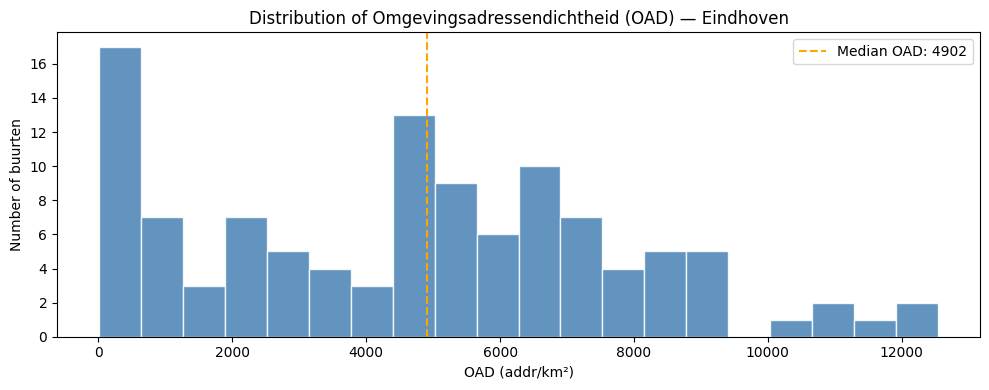

OAD stats:
count      111.00
mean      4670.04
std       3221.41
min          7.77
25%       1921.28
50%       4902.25
75%       6755.36
max      12542.14
Name: OAD, dtype: float64

Skewness: 0.24

Top 10 most dense buurten:
                   BUURTNAAM          OAD
                 Rochusbuurt 12542.138949
                  Witte Dame 12248.260545
                Kruidenbuurt 11704.793324
                 Hemelrijken 11118.718230
Eliasterrein, Vonderkwartier 10953.883036
                    Strijp S 10418.650053
               Limbeek-Noord  9361.845783
                      Schoot  9257.042045
                Bloemenplein  9248.541222
               Joriskwartier  9008.692609


In [35]:
# ── EDA: Address Density (OAD) ─────────────────────────────────────────────

if 'OAD' in ds3.columns and ds3['OAD'].notna().sum() > 1:

    df_eda = ds3.copy()

    # ensure numeric safety
    df_eda["OAD"] = pd.to_numeric(df_eda["OAD"], errors="coerce")

    # clean series
    oad = df_eda["OAD"].dropna()

    # ── FIGURE 1: distribution (correct EDA view) ──────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.hist(oad, bins=20, color="steelblue", edgecolor="white", alpha=0.85)

    median_oad = oad.median()

    ax.axvline(
        median_oad,
        color="orange",
        linestyle="--",
        label=f"Median OAD: {median_oad:.0f}"
    )

    ax.set_xlabel("OAD (addr/km²)")
    ax.set_ylabel("Number of buurten")
    ax.set_title("Distribution of Omgevingsadressendichtheid (OAD) — Eindhoven")
    ax.legend()
    plt.savefig('../figures/ds3_oad_distribution.png', dpi=150, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

    # ── SUMMARY STATS ───────────────────────────────────────────────────────
    print("OAD stats:")
    print(oad.describe().round(2))

    print("\nSkewness:", oad.skew().round(2))

    # ── TOP 10 MOST DENSE BUURTEN ───────────────────────────────────────────
    top10 = (
        df_eda[['BUURTNAAM', 'OAD']]
        .dropna()
        .sort_values('OAD', ascending=False)
        .head(10)
    )

    print("\nTop 10 most dense buurten:")
    print(top10.to_string(index=False))

else:
    print("OAD column missing or insufficient data")

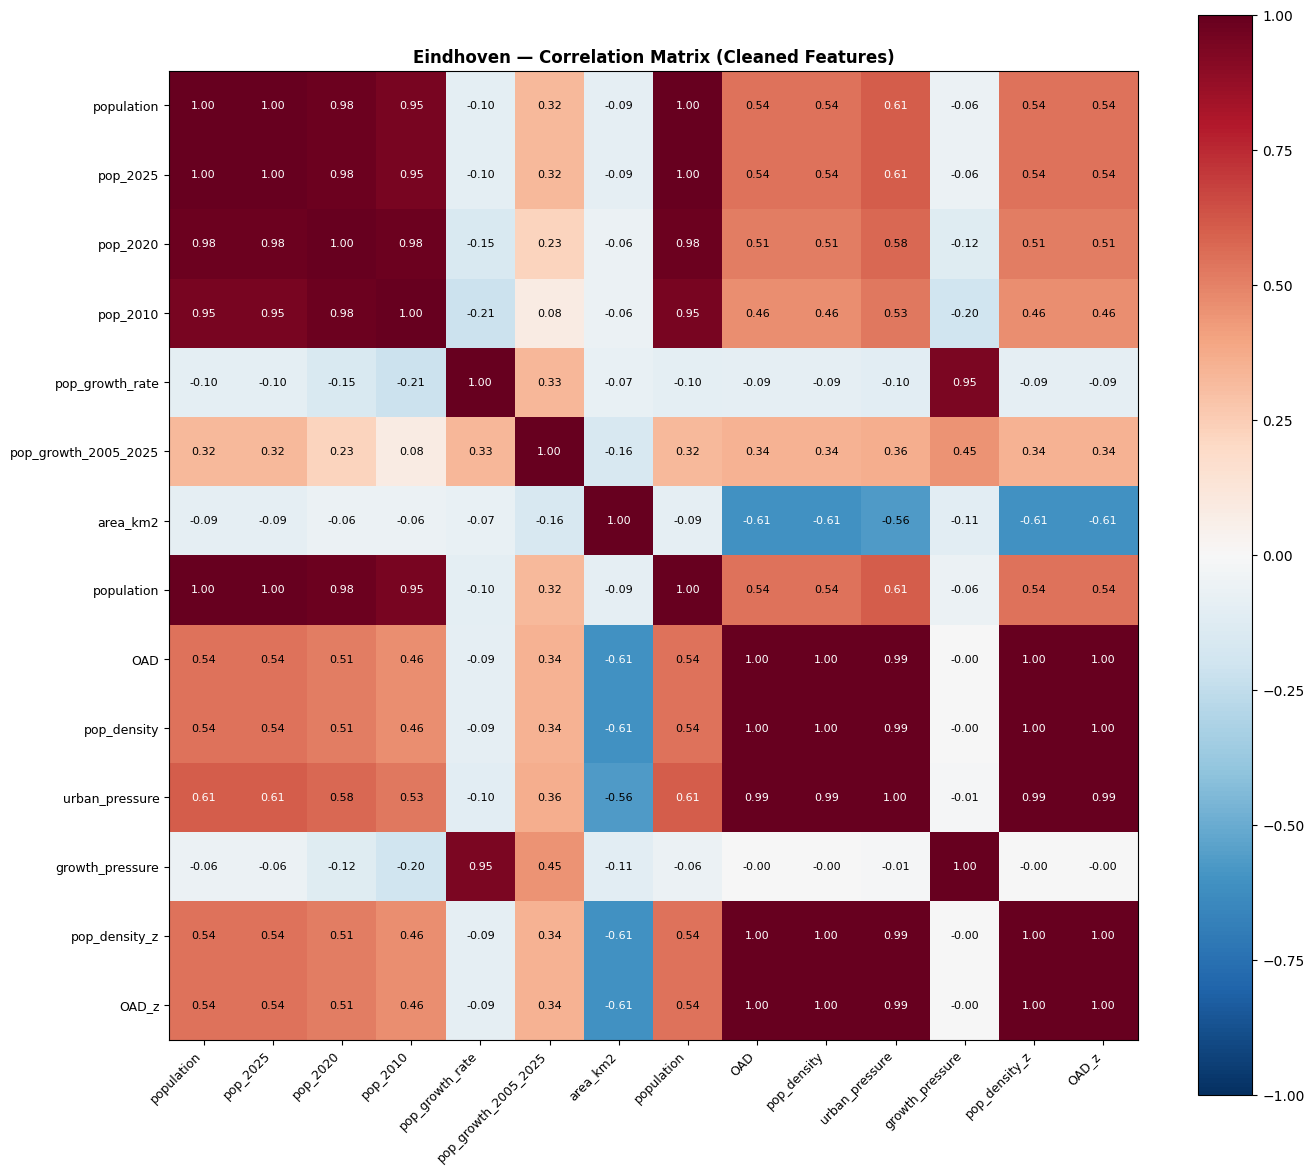

Strong correlations (|r| > 0.5):
  population × pop_2025: r = 1.000
  population × pop_2020: r = 0.981
  population × pop_2010: r = 0.953
  population × population: r = 1.000
  population × OAD: r = 0.543
  population × pop_density: r = 0.543
  population × urban_pressure: r = 0.608
  population × pop_density_z: r = 0.543
  population × OAD_z: r = 0.543
  pop_2025 × pop_2020: r = 0.981
  pop_2025 × pop_2010: r = 0.953
  pop_2025 × population: r = 1.000
  pop_2025 × OAD: r = 0.543
  pop_2025 × pop_density: r = 0.543
  pop_2025 × urban_pressure: r = 0.608
  pop_2025 × pop_density_z: r = 0.543
  pop_2025 × OAD_z: r = 0.543
  pop_2020 × pop_2010: r = 0.978
  pop_2020 × population: r = 0.981
  pop_2020 × OAD: r = 0.512
  pop_2020 × pop_density: r = 0.512
  pop_2020 × urban_pressure: r = 0.576
  pop_2020 × pop_density_z: r = 0.512
  pop_2020 × OAD_z: r = 0.512
  pop_2010 × population: r = 0.953
  pop_2010 × urban_pressure: r = 0.530
  pop_growth_rate × growth_pressure: r = 0.945
  area_km2 ×

<Figure size 640x480 with 0 Axes>

In [36]:
# ── EDA 3: Correlation matrix of key numeric variables ─────────────────────

# only use columns that actually exist in your dataset
candidate_cols = [
    'population',
    'pop_2025',
 'pop_2020',
 'pop_2010',
 'pop_growth_rate',
 'pop_growth_2005_2025',
 'area_km2',
 'population',
 'OAD',
 'pop_density',
 'urban_pressure',
 'growth_pressure',
 'pop_density_z',
 'OAD_z']


numeric_cols = [
    c for c in candidate_cols
    if c in ds3.columns and ds3[c].notna().sum() > 3
]

if len(numeric_cols) >= 2:

    df_corr = ds3[numeric_cols].copy()

    # force numeric safety
    df_corr = df_corr.apply(lambda x: pd.to_numeric(x, errors='coerce'))

    corr = df_corr.corr()

    fig, ax = plt.subplots(
        figsize=(max(6, len(numeric_cols)), max(5, len(numeric_cols)))
    )

    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, shrink=0.8)

    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(numeric_cols, fontsize=9)

    # annotate values
    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            val = corr.iloc[i, j]
            ax.text(
                j, i,
                f'{val:.2f}',
                ha='center',
                va='center',
                fontsize=8,
                color='white' if abs(val) > 0.6 else 'black'
            )

    ax.set_title('Eindhoven — Correlation Matrix (Cleaned Features)', fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.savefig('../figures/ds3_corr_matrix.png', dpi=150, bbox_inches='tight')


    # highlight strong relationships
    print("Strong correlations (|r| > 0.5):")
    for i in range(len(numeric_cols)):
        for j in range(i + 1, len(numeric_cols)):
            r = corr.iloc[i, j]
            if abs(r) > 0.5:
                print(f"  {numeric_cols[i]} × {numeric_cols[j]}: r = {r:.3f}")

else:
    print("Not enough valid numeric columns for correlation analysis")

**findings**:
- Population-related correlations
population × pop_2025: r = 1.000 → perfectly correlated (expected, since pop_2025 is essentially the same as population projection).
population × pop_2020: r = 0.981
population × pop_2010: r = 0.953
Interpretation: Population hasn’t changed drastically; historical and projected populations are tightly correlated with current population.
- Population & density / address density
population × pop_density: r = 0.543 → moderate positive correlation.
population × OAD: r = 0.543 → moderate positive correlation.
pop_density × OAD: r = 1.000 → perfect correlation.
Interpretation:
OAD (address density) scales linearly with pop_density.
More densely populated buurten naturally have more addresses.
Because of this, you only need either pop_density or OAD for analyses related to density — using both would be redundant.
- Area-related correlations
area_km2 × OAD: r = -0.607
area_km2 × pop_density: r = -0.607
area_km2 × urban_pressure: r = -0.563
Interpretation: Larger buurten tend to have lower population density and lower address density — small buurten are “urban cores” with higher density.
- Growth metrics
pop_growth_rate × growth_pressure: r = 0.945
Interpretation: Growth-related variables are very tightly correlated, as expected. Only one needs to be used if you want to avoid redundancy.

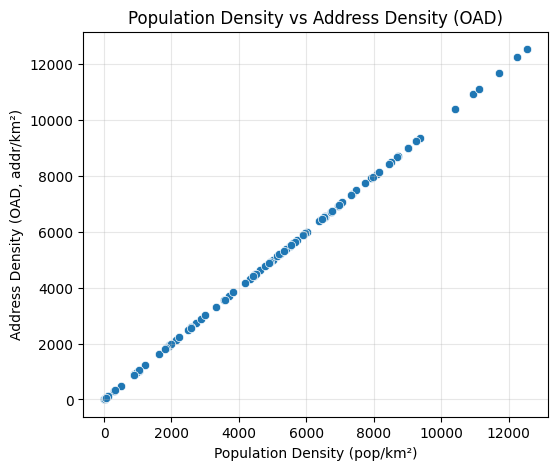

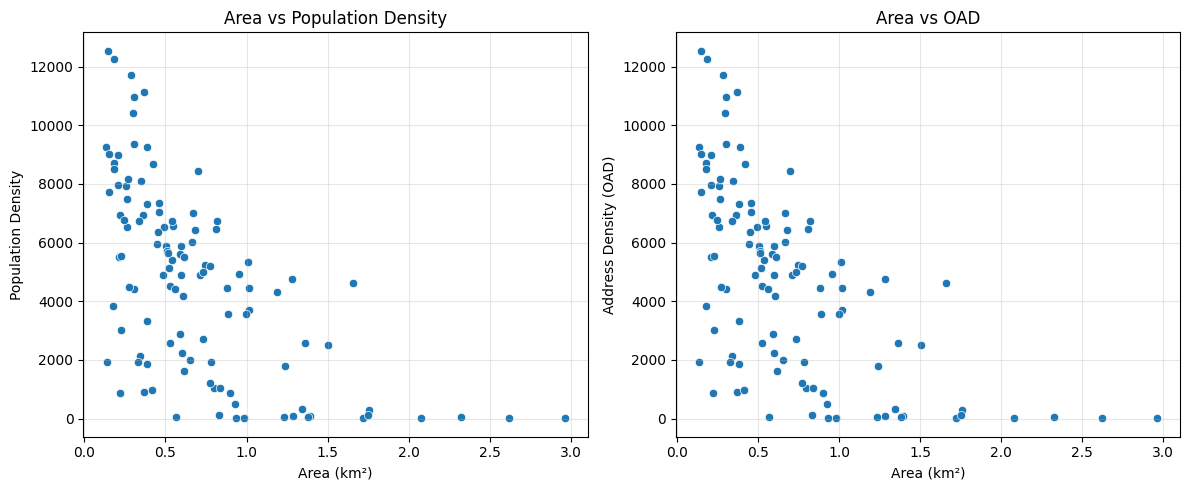

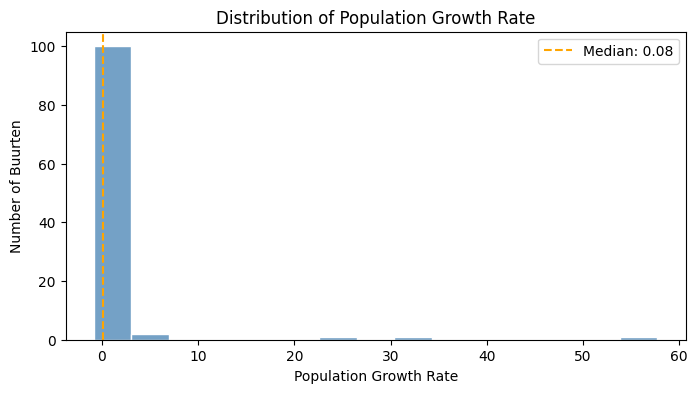

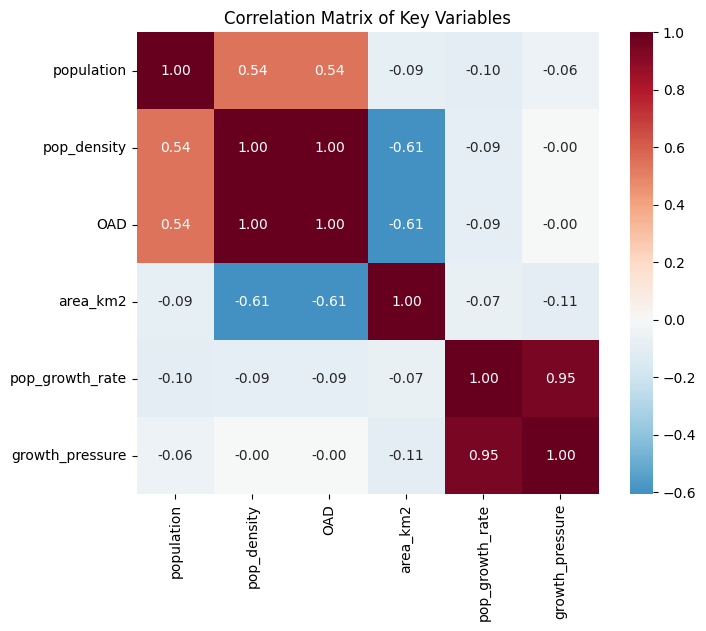

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Select numeric columns ─────────────────────────────────────────────
numeric_cols = [
    "population",      # current population
    "pop_density",     # population density
    "OAD",             # address density (OAD)
    "area_km2",        # neighborhood size
    "pop_growth_rate", # population growth rate
    "growth_pressure"  # growth pressure
]
numeric_cols = [c for c in numeric_cols if c in ds3.columns]

# ── 2. Filter rows safely ────────────────────────────────────────────────
# If 'hasDataGap' exists, exclude those rows; else, keep all rows
if 'hasDataGap' in ds3.columns:
    df = ds3.loc[ds3['hasDataGap'] == False, numeric_cols + ['BUURTNAAM']].copy()
else:
    df = ds3[numeric_cols + ['BUURTNAAM']].copy()

# ── 3. Population Density vs OAD ────────────────────────────────────────
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["pop_density"], y=df["OAD"])
plt.xlabel("Population Density (pop/km²)")
plt.ylabel("Address Density (OAD, addr/km²)")
plt.title("Population Density vs Address Density (OAD)")
plt.grid(True, alpha=0.3)
plt.show()

# ── 4. Area vs Population Density / OAD ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(x=df["area_km2"], y=df["pop_density"], ax=axes[0])
axes[0].set_xlabel("Area (km²)")
axes[0].set_ylabel("Population Density")
axes[0].set_title("Area vs Population Density")
axes[0].grid(True, alpha=0.3)

sns.scatterplot(x=df["area_km2"], y=df["OAD"], ax=axes[1])
axes[1].set_xlabel("Area (km²)")
axes[1].set_ylabel("Address Density (OAD)")
axes[1].set_title("Area vs OAD")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 5. Growth metrics histogram ─────────────────────────────────────────
if "pop_growth_rate" in df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df["pop_growth_rate"].dropna(), bins=15, color="steelblue", edgecolor="white")
    plt.axvline(df["pop_growth_rate"].median(), color="orange", linestyle="--", 
                label=f"Median: {df['pop_growth_rate'].median():.2f}")
    plt.xlabel("Population Growth Rate")
    plt.ylabel("Number of Buurten")
    plt.title("Distribution of Population Growth Rate")
    plt.legend()
    plt.show()

# ── 6. Correlation matrix ───────────────────────────────────────────────
plt.figure(figsize=(8,6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation Matrix of Key Variables")
plt.show()

- nearly perfect linear relationship between pop_density and adress density
- Small-area buurten often have very high population density and high OAD. Larger-area buurten tend to have lower density and lower OAD.
- most buurten have very low growth, but few outliers with extremely high growth rates.

In [38]:
# ── Save clean DS3 ─────────────────────────────────────────────────────────
ds3.to_csv('../data/clean/ds3.csv', index=False)
print(f'Saved: ds3.csv ({len(ds3)} rows, {len(ds3.columns)} columns)')
print('Columns:', ds3.columns.tolist())

Saved: ds3.csv (111 rows, 40 columns)
Columns: ['BUURTNAAM', 'BUURTCODE', 'WIJKNAAM', 'STADSDEELNAAM', 'geo_shape', 'Inwoners|2005', 'Inwoners|2006', 'Inwoners|2007', 'Inwoners|2008', 'Inwoners|2009', 'Inwoners|2010', 'Inwoners|2011', 'Inwoners|2012', 'Inwoners|2013', 'Inwoners|2014', 'Inwoners|2015', 'Inwoners|2016', 'Inwoners|2017', 'Inwoners|2018', 'Inwoners|2019', 'Inwoners|2020', 'Inwoners|2021', 'Inwoners|2022', 'Inwoners|2023', 'Inwoners|2024', 'Inwoners|2025', 'geometry', 'pop_2025', 'pop_2020', 'pop_2010', 'pop_growth_rate', 'pop_growth_2005_2025', 'area_km2', 'population', 'OAD', 'pop_density', 'urban_pressure', 'growth_pressure', 'pop_density_z', 'OAD_z']
